In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import pyproj
from rasterio.transform import Affine

import dask.dataframe as dd
import matplotlib.pyplot as plt
import matplotlib.colors as cl

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo

crs = ccrs.PlateCarree()
import cmocean.cm as cm

from xgcm import Grid
from xhistogram.xarray import histogram
import warnings

warnings.filterwarnings("ignore")

import os
from glob import glob

import histlib.box as box
import histlib.aviso as aviso
import histlib.cstes as cstes
import histlib.diagnosis as diag
from histlib.diagnosis import put_fig_letter
from histlib.cstes import labels, zarr_dir, matchup_dir, U

U2 = U**2

/home1/datahome/mdemol/.miniconda3/envs/histenv2/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.scheduler.transition-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(
/home1/datahome/mdemol/.miniconda3/envs/histenv2/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.comm.recent-messages-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(


In [2]:
if True:
    from dask.distributed import Client
    from dask_jobqueue import PBSCluster

    # cluster = PBSCluster(cores=56, processes=28, walltime='04:00:00')
    # cluster = PBSCluster(cores=7, processes=7, walltime='04:00:00')
    cluster = PBSCluster(cores=5, processes=5, walltime="02:00:00")
    w = cluster.scale(jobs=4)
    # w = cluster.scale(jobs=3)
else:
    from dask.distributed import Client, LocalCluster

    cluster = LocalCluster()

client = Client(cluster)
client

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: http://10.148.0.251:8787/status,
Dashboard: http://10.148.0.251:8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://10.148.0.251:43715,Workers: 0
Dashboard: http://10.148.0.251:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


# Create csv files

In [6]:
zarrs_cutoff = sorted(
    glob(
        os.path.join(
            "/home/datawork-lops-oc/aponte/margot/historical_coloc_ok/cutoff_matchup",
            "*_2.zarr",
        )
    )
)

In [7]:
zarrs = sorted(
    glob(
        os.path.join(
            "/home/datawork-lops-oc/aponte/margot/historical_coloc_ok/matchup", "*"
        )
    )
)

In [8]:
for i in range(len(zarrs)):
    ds0 = xr.open_dataset(zarrs_cutoff[i])[
        ["drifter_acc_x_25", "drifter_coriolis_x_25"]
    ]
    ds1 = xr.open_dataset(zarrs[i])[
        [
            "drogue_status",
            "drifter_acc_x_0",
            "drifter_coriolis_x_0",
            "alti_ggx_adt_filtered_ocean_tide_internal_tide",
            "aviso_alti_ggx_adt",
            "aviso_drifter_ggx_adt",
            "es_cstrio_z15_drifter_wd_x",
            "es_cstrio_z15_alti_wd_x",
        ]
    ]
    path = os.path.join(
        "/home/datawork-lops-oc/aponte/margot/historical_coloc_ok/coloc_err",
        zarrs[i].split("/")[-1].replace("zarr", "csv"),
    )
    df = xr.merge([ds0, ds1]).to_dataframe()
    df.where(df.drogue_status).dropna().to_csv(path)  # only drogued drifters
    print(path)

/home/datawork-lops-oc/aponte/margot/historical_coloc_ok/coloc_err/matchup_argos_Cryosat-2_2010.csv
/home/datawork-lops-oc/aponte/margot/historical_coloc_ok/coloc_err/matchup_argos_Cryosat-2_2011.csv
/home/datawork-lops-oc/aponte/margot/historical_coloc_ok/coloc_err/matchup_argos_Cryosat-2_2012.csv
/home/datawork-lops-oc/aponte/margot/historical_coloc_ok/coloc_err/matchup_argos_Cryosat-2_2013.csv
/home/datawork-lops-oc/aponte/margot/historical_coloc_ok/coloc_err/matchup_argos_Cryosat-2_2014.csv
/home/datawork-lops-oc/aponte/margot/historical_coloc_ok/coloc_err/matchup_argos_Cryosat-2_2015.csv
/home/datawork-lops-oc/aponte/margot/historical_coloc_ok/coloc_err/matchup_argos_Cryosat-2_2016.csv
/home/datawork-lops-oc/aponte/margot/historical_coloc_ok/coloc_err/matchup_argos_Cryosat-2_2017.csv
/home/datawork-lops-oc/aponte/margot/historical_coloc_ok/coloc_err/matchup_argos_Cryosat-2_2018.csv
/home/datawork-lops-oc/aponte/margot/historical_coloc_ok/coloc_err/matchup_argos_Cryosat-2_2019.csv


# Preparation

In [2]:
zarrs = glob(
    os.path.join(
        "/home/datawork-lops-oc/aponte/margot/historical_coloc_ok/coloc_err", "*"
    )
)

In [3]:
df = dd.concat([pd.read_csv(z) for z in zarrs])

In [4]:
df = df.compute()

In [5]:
len(df)

1895028

In [6]:
dl = 5000
df["distbin"] = (df.alti___distance // dl) * dl / 1000

In [7]:
df = df.rename(
    columns={
        "aviso_alti_ggx_adt": "ggx",
        "aviso_drifter_ggx_adt": "ggxd",
        "drifter_acc_x_25": "acc",
        "drifter_coriolis_x_25": "cor",
        "es_cstrio_z15_drifter_wd_x": "wd",
    }
)[
    [
        "obs",
        "acc",
        "cor",
        "drogue_status",
        "ggx",
        "ggxd",
        "wd",
        "alti___distance",
        "alti___time_difference",
        "lat",
        "lon",
        "time",
        "distbin",
    ]
]

for v in [
    v
    for v in df
    if v
    not in [
        "obs",
        "drogue_status",
        "alti___distance",
        "alti___time_difference",
        "lat",
        "lon",
        "time",
        "distbin",
    ]
]:
    df[v] = df[v] / U

In [8]:
df["da"] = df.ggx - df.ggxd  # ggx diff
df["sd"] = df.acc + df.cor + df.ggxd + df.wd  # s (no coloc error)
df["s"] = df.acc + df.cor + df.ggx + df.wd  # s* with colocation error

var = ["acc", "cor", "ggx", "wd"]
vard = ["acc", "cor", "ggxd", "wd"]

# Correlation with ggx diff
for v in var:
    df[v + "da"] = df.da * df[v]
df["ggxdda"] = df.da * df.ggxd

df["sda"] = df["da"] * df["s"]
df["sdda"] = df["da"] * df["sd"]

df2 = (
    df[
        [
            v
            for v in df
            if v
            not in [
                "obs",
                "drogue_status",
                "alti___distance",
                "alti___time_difference",
                "lat",
                "lon",
                "time",
                "distbin",
            ]
        ]
    ]
    ** 2
)  # mean square values
df2["distbin"] = df["distbin"]

In [39]:
df_ = df.where(df.alti___distance < 25000).dropna()
df2_ = df2.where(df.alti___distance < 25000).dropna()
print(len(df_))

238566


_________
# Distribution on DL

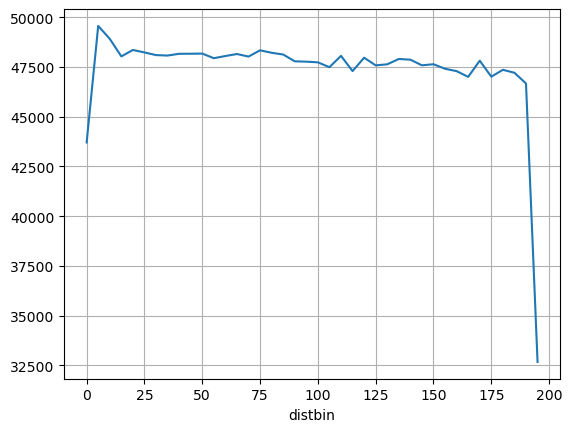

In [40]:
count = df.groupby("distbin").ggx.count()
count.plot()
plt.grid()

____________
___________

# Notations

Consider two different reconstructions that distinguish themselves by the estimation of the $k$-term:

\begin{align}
        &\sum_i{a_i} = \epsilon\\
        &\sum_{i \neq k}{a_i} + a_k^* = \epsilon^*
\end{align}


where the $a_k$ estimate of the $k$-term is replaced by a estimate $a^*_k$.

Denoting all the metrics related with reconstruction (\ref{eq : eq1}) with an $^*$ and the difference in between these two estimates $d_k = a^*_k -a_k = \epsilon^*-\epsilon$ (i.e. the additional error), we can derive the effect of such change on the different metrics we use :

\begin{align}
    \beta^*  &= \beta - 2 \langle d_k \epsilon_{-k} \rangle \label{eq : general beta star}\\
    \mathcal{E}^*  &= \langle (\epsilon + d_k)^2 \rangle  \\
    &= \mathcal{E} + D_k + 2\langle d_k \epsilon \rangle \label{eq : general s}
\end{align}

For $i\neq k$ :
\begin{equation}
\begin{dcases}
\beta_i^* = -\sum_{j\neq i} \langle a_ia_j \rangle -\langle d_k a_i\rangle = \beta_i -\langle d_k a_i  \rangle\\
\mathcal{E}_i^* = \langle a_i \epsilon^*\rangle  = \mathcal{E}_i + \langle d_k a_i  \rangle
\label{eq : ineqk coloc}
\end{dcases}
\end{equation}

For $i=k$ :
\begin{equation}
\begin{dcases}
\beta_k^* &= -\sum_{j \neq k }\langle a_k^* a_j \rangle = \beta_k -\sum_{j\neq k} \langle d_k a_j \rangle = \beta_k - \langle d_k \epsilon_{-k} \rangle \\
\mathcal{E}_k^*  &= \langle a^*_k \epsilon^* \rangle = \langle (a_k + d_k)(s + d_k +a_k -a_k)\rangle = \langle  a_k(s-a_k) + d_k (s-a_k) +(a_k + d_k)^2\rangle \\
&= \mathcal{E}_k + \langle d_k \epsilon_{-k}\rangle + A^*_k-A_k \\
&= \mathcal{E}_k + D_k + \langle d_k (\epsilon + a_k) \rangle
\label{eq : i=k coloc}
\end{dcases}
\end{equation}

For i,j $\neq$ k :
\begin{equation}
    X^*_{i,j} = X_{i,j}
\end{equation}
For $i=k$ (or $j=k$) :
\begin{equation}
    X^*_{k,j} = X_{k,j} -2 \langle d_k a_j \rangle \label{eq: Xij star ik}
\end{equation}


____________
____________

# Residual MS

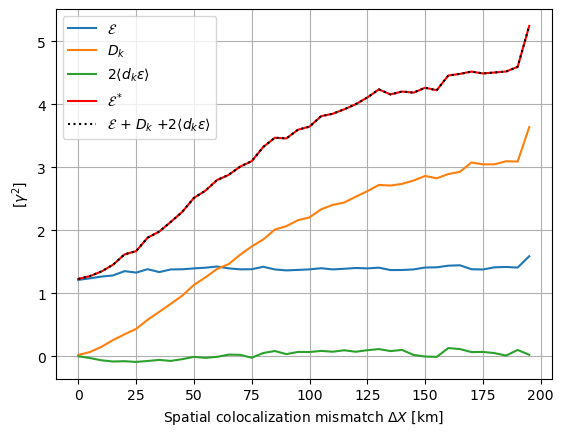

In [9]:
df2["sd2_da2_2sdda"] = df2.sd + df2.da + 2 * df.sdda
df2.groupby("distbin").sd.mean().plot(label=r"$\mathcal{E}$")
df2.groupby("distbin").da.mean().plot(label=r"$D_k$")
(df.groupby("distbin").sdda.mean() * 2).plot(label=r"$2\langle d_k \epsilon \rangle$")

df2.groupby("distbin").s.mean().plot(label=r"$\mathcal{E}^*$", c="r")
df2.groupby("distbin").sd2_da2_2sdda.mean().plot(
    label=r"$\mathcal{E}$ + $D_k$ +$2\langle d_k \epsilon \rangle$", c="k", ls=":"
)

plt.xlabel("Spatial colocalization mismatch $\Delta X$ [km]")
plt.ylabel(r"[$\gamma^2$]")
plt.legend()
plt.grid()

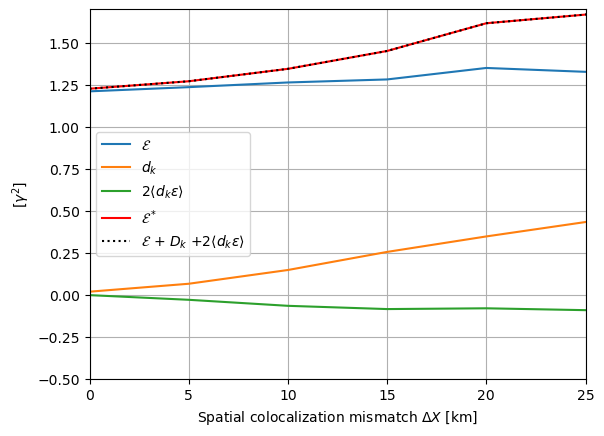

In [47]:
df2["sd2_da2_2sdda"] = df2.sd + df2.da + 2 * df.sdda
df2.groupby("distbin").sd.mean().plot(label=r"$\mathcal{E}$")
df2.groupby("distbin").da.mean().plot(label=r"$d_k$")
(df.groupby("distbin").sdda.mean() * 2).plot(label=r"$2\langle d_k \epsilon \rangle$")

df2.groupby("distbin").s.mean().plot(label=r"$\mathcal{E}^*$", c="r")
df2.groupby("distbin").sd2_da2_2sdda.mean().plot(
    label=r"$\mathcal{E}$ + $D_k$ +$2\langle d_k \epsilon \rangle$", c="k", ls=":"
)

plt.xlabel("Spatial colocalization mismatch $\Delta X$ [km]")
plt.ylabel(r"[$\gamma^2$]")
plt.xlim(0, 25)
plt.ylim(-0.5, 1.7)
plt.legend()
plt.grid()

In [99]:
low = df2_.groupby("distbin").s.mean().iloc[0:2].mean()
print(low, df2_["s"].mean())
(df2_["s"].mean() - low) / (df2_["s"].mean())

1.2484194194833016 1.3839262837845971


0.09791479928448753

In [100]:
2 * df_["sdda"].mean() / df2_["da"].mean()

-0.3191773342107646

In [94]:
df2_["da"].mean() / df2_["s"].mean()

0.121883675041406

In [102]:
2 * df_["sdda"].mean() / df2_["s"].mean()

-0.03890250648352707

In [95]:
(df2_["da"].mean() + 2 * df_["sdda"].mean()) / df2_["s"].mean()

0.08298116855787893

____________
____________
# Balanced signal contributions


In [103]:
from itertools import combinations

comb = list(combinations(var, 2))
combd = list(combinations(vard, 2))
for c in comb:
    df[f"{c[0]}_{c[1]}"] = df[c[0]] * df[c[1]]
for c in combd:
    df[f"{c[0]}_{c[1]}"] = df[c[0]] * df[c[1]]

In [104]:
for v in var:
    df["b_" + v] = -df[[f"{c[0]}_{c[1]}" for c in comb if v in f"{c[0]}_{c[1]}"]].sum(
        axis=1
    )

for v in vard:
    df["bd_" + v] = -df[[f"{c[0]}_{c[1]}" for c in combd if v in f"{c[0]}_{c[1]}"]].sum(
        axis=1
    )

In [135]:
df_ = df.where(df.alti___distance < 25000).dropna()
df2_ = df2.where(df.alti___distance < 25000).dropna()
print(len(df_))

238566


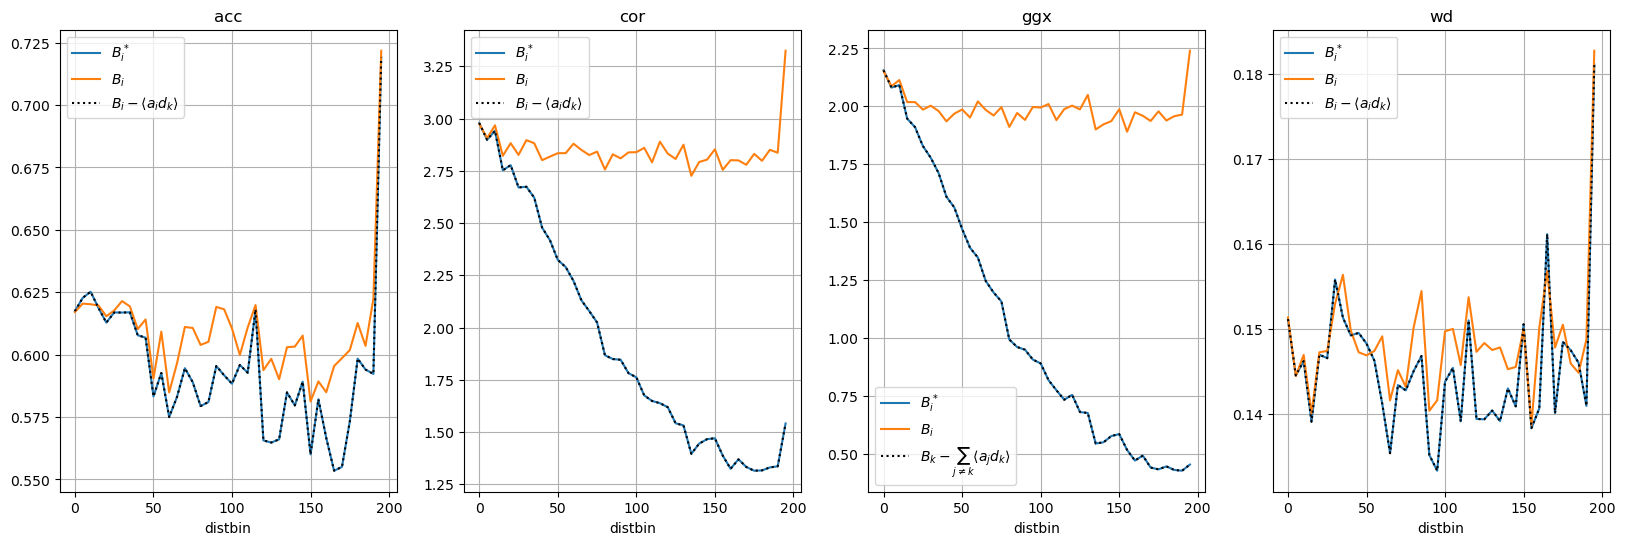

In [105]:
fig, axs = plt.subplots(1, 4, figsize=(20, 6))
axs = axs.flatten()
for i in range(len(var)):
    ax = axs[i]
    v, vd = var[i], vard[i]
    df.groupby("distbin")["b_" + v].mean().plot(label=r"$B^*_i$", ax=ax)
    df.groupby("distbin")["bd_" + vd].mean().plot(label=r"$B_i$", ax=ax)
    if v != "ggx":
        (
            -df.groupby("distbin")[v + "da"].mean()
            + df.groupby("distbin")["bd_" + vd].mean()
        ).plot(label=r"$B_i - \langle a_i d_k \rangle$", ax=ax, c="k", ls=":")
    else:
        (
            -df.groupby("distbin")[[u + "da" for u in var if u != "ggx"]]
            .mean()
            .sum(axis=1)
            + df.groupby("distbin")["bd_" + vd].mean()
        ).plot(
            label=r"$B_k - \sum_{j\neq k}\langle a_j d_k \rangle$", ax=ax, c="k", ls=":"
        )
    # (df.groupby("distbin")[vd+'e'].mean() + df.groupby("distbin")['bd_'+vd].mean()).plot(label=r'$B_i + \langle a_i e \rangle$', ax=ax, c='b', ls=':')
    ax.grid()
    ax.set_title(v)
    ax.legend()

In [137]:
df_

,obs,acc,cor,drogue_status,ggx,ggxd,wd,alti___distance,alti___time_difference,lat,...,ggxs,wds,accsd,corsd,ggxdsd,wdsd,sumb,sumbd,sume,sumed
0,5,0.139134,-0.155076,True,0.162015,0.046806,-0.231884,9757.0,114.0,19.56126,...,-0.013903,0.019898,-0.027969,0.031173,-0.009409,0.046614,0.116063,0.058959,0.007364,0.040409
5,20,-0.403839,0.113508,True,0.416886,0.257179,0.04815,7356.0,1289.0,32.755119,...,0.072832,0.008412,-0.006057,0.001702,0.003857,0.000722,0.321561,0.244205,0.030522,0.000225
13,41,-0.232424,0.024048,True,-0.098771,-0.152633,-0.094473,9502.0,1479.0,51.9589,...,0.039669,0.037942,0.105865,-0.010953,0.069521,0.043031,-0.088019,-0.120642,0.161299,0.207463
16,47,1.399281,4.739683,True,-6.328075,-6.326668,0.413546,2407.0,526.0,54.038559,...,-1.420235,0.092814,0.316016,1.070418,-1.428825,0.093396,64.587772,64.569325,0.050371,0.051004
19,50,0.163943,-0.146158,True,-0.619948,-0.060505,0.111641,19101.0,1711.0,41.669159,...,0.304098,-0.054762,0.011299,-0.010073,-0.00417,0.007694,0.204426,0.059614,0.240612,0.004750
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5840,11688,0.315961,0.653661,True,-0.367555,-0.367799,-0.325989,3107.0,410.0,-55.280239,...,-0.101474,-0.089998,0.087152,0.180301,-0.101451,-0.089919,0.692250,0.692565,0.076219,0.076084
5849,11700,-0.287697,-0.226492,True,-0.043605,-0.045673,-0.006943,5563.0,877.0,28.039391,...,0.024626,0.003921,0.163068,0.128376,0.025888,0.003935,-0.182910,-0.185065,0.318927,0.321267
5851,11708,0.488784,0.560942,True,-0.602777,-0.602506,0.007015,1353.0,558.0,-9.65676,...,-0.273639,0.003184,0.222022,0.254799,-0.273679,0.003186,0.710871,0.710300,0.206083,0.206328
5855,11715,-0.07987,0.66242,True,-0.577234,-0.727846,-0.170575,18116.0,1032.0,-25.31888,...,0.095393,0.028189,0.025228,-0.209239,0.229905,0.053879,0.780164,0.904261,0.027310,0.099774


In [138]:
for i in range(len(var)):
    ax = axs[i]
    v, vd = var[i], vard[i]
    print(v + f'   {-df_[v + "da"].mean()/df_["bd_"+vd].mean()*100}')
    print(v + f'   {-df_[v + "da"].mean()/df_["b_"+v].mean()*100}')

acc   0.13872488935149271
acc   0.13853271000282566
cor   -1.429590958309415
cor   -1.4503246686384004
ggx   -4.844753314590433
ggx   -4.942706666210141
wd   -0.2875241242425347
wd   -0.28835320928224867


# Residual contribution

In [124]:
for v in var:
    df[v + "s"] = df[v] * df["s"]
    df2[v + "s"] = df[v + "s"]

for v in vard:
    df[v + "sd"] = df[v] * df["sd"]
    df2[v + "sd"] = df[v + "sd"]

df["sumb"] = df[["b_" + v for v in var]].sum(axis=1)
df["sumbd"] = df[["bd_" + v for v in vard]].sum(axis=1)
df["sume"] = df[[v + "s" for v in var]].sum(axis=1)
df["sumed"] = df[[v + "sd" for v in vard]].sum(axis=1)

df_ = df.where(df.alti___distance < 25).dropna()
df2_ = df2.where(df.alti___distance < 25).dropna()

In [154]:
for i in range(len(var)):
    ax = axs[i]
    v, vd = var[i], vard[i]
    if v != "ggx":
        print(v + f'   {df_[v + "da"].mean()/df_[v + "s"].mean()*100}')
    else:
        a = (
            df_[[u + "da" for u in var if u != "ggx"]].sum(axis=1).mean()
            - df2_["ggx"].mean()
            + df2_["ggxd"].mean()
        )
        print(v + f'   {a/df_[v + "s"].mean()*100}')
        print(f'A*_k-A_k : {- df2_["ggx"].mean()+ df2_["ggxd"].mean()}')
        print(f'dkak : {df_[[u + "da" for u in var if u != "ggx"]].sum(axis=1).mean()}')

acc   -0.21156376645131134
cor   4.2988857427283245
ggx   -63.79051652093276
A*_k-A_k : -0.03253316990155097
dkak : 0.04115332516245826
wd   1.726078527215486


In [148]:
df_[[u + "da" for u in var if u != "ggx"]].mean().sum()

0.04115332516245849

In [149]:
df2_["ggx"].mean() - df2_["ggxd"].mean()

0.03253316990155097

In [150]:
df_[v + "s"].mean()

0.0243002796320473

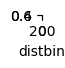

In [125]:
#
fig, ax = plt.subplots(1, 1, figsize=(0, 0), sharex=True)
v, vd = var[0], vard[0]
df.groupby("distbin")[v + "s"].mean().plot(
    label=r"$\epsilon^*_i$ - AVISO altimeter matchup", ax=ax, c="b"
)
df.groupby("distbin")[vd + "sd"].mean().plot(
    label=r"$\epsilon_i$ - AVISO drifter matchup", ax=ax, c="g"
)
df.groupby("distbin")["b_" + v].mean().plot(
    label=r"$\beta^*_i$ - AVISO altimeter matchup", ax=ax, c="r"
)
df.groupby("distbin")["bd_" + vd].mean().plot(
    label=r"$\beta_i$ - AVISO drifter matchup", ax=ax, c="orange"
)
handlest, labelst = ax.get_legend_handles_labels()

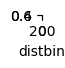

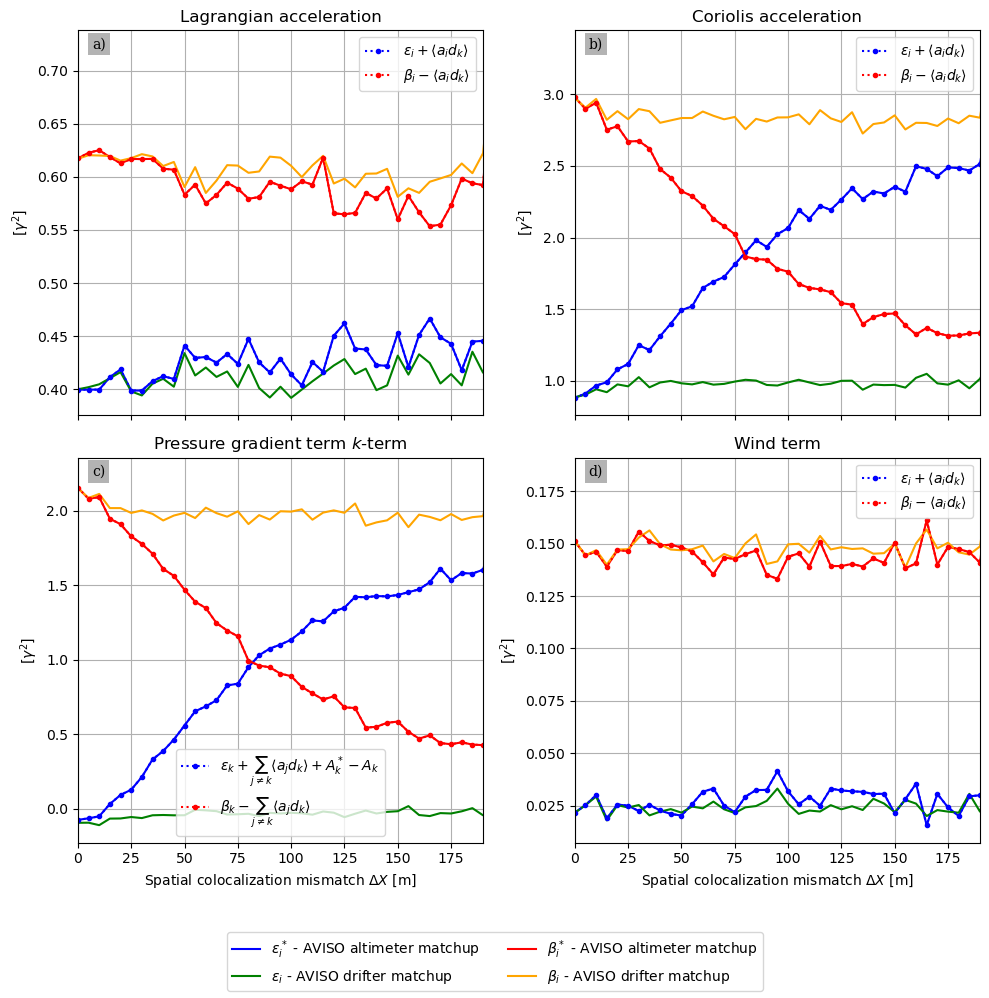

In [159]:
# get fig labels
fig, ax = plt.subplots(1, 1, figsize=(0, 0), sharex=True)
v, vd = var[0], vard[0]
df.groupby("distbin")[v + "s"].mean().plot(
    label=r"$\epsilon^*_i$ - AVISO altimeter matchup", ax=ax, c="b"
)
df.groupby("distbin")[vd + "sd"].mean().plot(
    label=r"$\epsilon_i$ - AVISO drifter matchup", ax=ax, c="g"
)
df.groupby("distbin")["b_" + v].mean().plot(
    label=r"$\beta^*_i$ - AVISO altimeter matchup", ax=ax, c="r"
)
df.groupby("distbin")["bd_" + vd].mean().plot(
    label=r"$\beta_i$ - AVISO drifter matchup", ax=ax, c="orange"
)
handlest, labelst = ax.get_legend_handles_labels()

#
fig, axs = plt.subplots(2, 2, figsize=(10, 10), sharex=True)
axs = axs.flatten()
Titles = [
    r"Lagrangian acceleration",
    r"Coriolis acceleration",
    r"Pressure gradient term $k$-term",
    r"Wind term",
]
letters = ["a", "b", "c", "d"]
for i in range(len(var)):
    ax = axs[i]
    v, vd = var[i], vard[i]
    if v != "ggx":
        df.groupby("distbin")[v + "s"].mean().plot(ax=ax, c="b")
        df.groupby("distbin")[vd + "sd"].mean().plot(ax=ax, c="g")
        (
            df.groupby("distbin")[v + "da"].mean()
            + df.groupby("distbin")[vd + "sd"].mean()
        ).plot(
            label=r"$\epsilon_i + \langle a_i d_k \rangle$",
            ax=ax,
            c="b",
            ls=":",
            marker=".",
        )
    else:
        df.groupby("distbin")[v + "s"].mean().plot(ax=ax, c="b")
        df.groupby("distbin")[vd + "sd"].mean().plot(ax=ax, c="g")
        (
            df.groupby("distbin")[[u + "da" for u in var if u != "ggx"]]
            .mean()
            .sum(axis=1)
            + df2.groupby("distbin")["ggx"].mean()
            - df2.groupby("distbin")["ggxd"].mean()
            + df.groupby("distbin")[vd + "sd"].mean()
        ).plot(
            label=r"$\epsilon_k + \sum_{j \neq k} \langle a_j d_k \rangle + A^*_k - A_k $",
            ax=ax,
            c="b",
            ls=":",
            marker=".",
        )
        # (df.groupby("distbin")[[u+'da' for u in var if u!='ggx']].mean().sum(axis=1)  + df.groupby("distbin")[vd+'sd'].mean()).plot(label=r"$E_{3eq} + \langle d_3\sum_{j\neq3} a_j) + a'^2_3 -a^2_3 \rangle$", ax=ax, c='g', ls=':')
    ax.grid()

for i in range(len(var)):
    ax = axs[i]
    v, vd = var[i], vard[i]
    df.groupby("distbin")["b_" + v].mean().plot(c="r", ax=ax)
    df.groupby("distbin")["bd_" + vd].mean().plot(c="orange", ax=ax)
    if v != "ggx":
        (
            -df.groupby("distbin")[v + "da"].mean()
            + df.groupby("distbin")["bd_" + vd].mean()
        ).plot(
            label=r"$\beta_i - \langle a_i d_k \rangle$",
            ax=ax,
            c="r",
            ls=":",
            marker=".",
        )
    else:
        (
            -df.groupby("distbin")[[u + "da" for u in var if u != "ggx"]]
            .mean()
            .sum(axis=1)
            + df.groupby("distbin")["bd_" + vd].mean()
        ).plot(
            label=r"$\beta_k- \sum_{j\neq k}\langle a_j d_k \rangle$",
            ax=ax,
            c="r",
            ls=":",
            marker=".",
        )
    # (df.groupby("distbin")[vd+'e'].mean() + df.groupby("distbin")['bd_'+vd].mean()).plot(label=r'$B_i + \langle a_i e \rangle$', ax=ax, c='b', ls=':')
    ax.grid()
    ax.set_title(Titles[i])
    ax.legend(ncol=2)
    ax.set_xlabel("Spatial colocalization mismatch $\Delta X$ [m]")
    ax.set_xlim(0, 190)
    ax.set_ylabel(r"[$\gamma^2$]")
    put_fig_letter(fig, ax, letters[i])
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[slice(2, 6, 3)], labels[slice(2, 6, 3)])

fig.legend(handlest, labelst, ncols=2, loc="lower center")
fig.tight_layout(rect=[0, 0.09, 1, 1])  # left, bottom, right, top (default is 0,0,1,1)

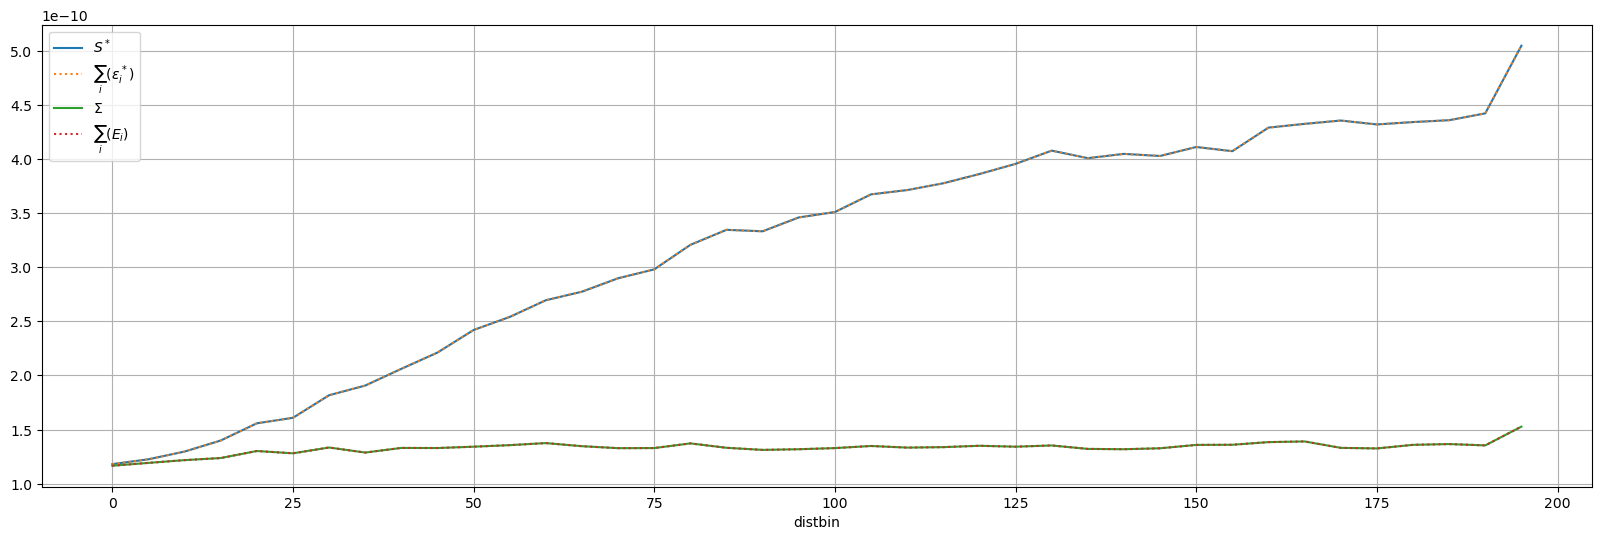

In [56]:
fig, ax = plt.subplots(1, 1, figsize=(20, 6))

df2.groupby("distbin")["s"].mean().plot(label=r"$\mathcal{E}^*$", ax=ax)
(df.groupby("distbin")["sume"].mean()).plot(
    label=r"$\sum_i(\epsilon^*_i)$", ax=ax, ls=":"
)

df2.groupby("distbin")["sd"].mean().plot(label=r"$\Sigma$", ax=ax)
(df.groupby("distbin")["sumed"].mean()).plot(label=r"$\sum_i(E_i)$", ax=ax, ls=":")
ax.grid()
ax.legend()

## Check $\beta_{i} + \epsilon_{i} = A_{i}$


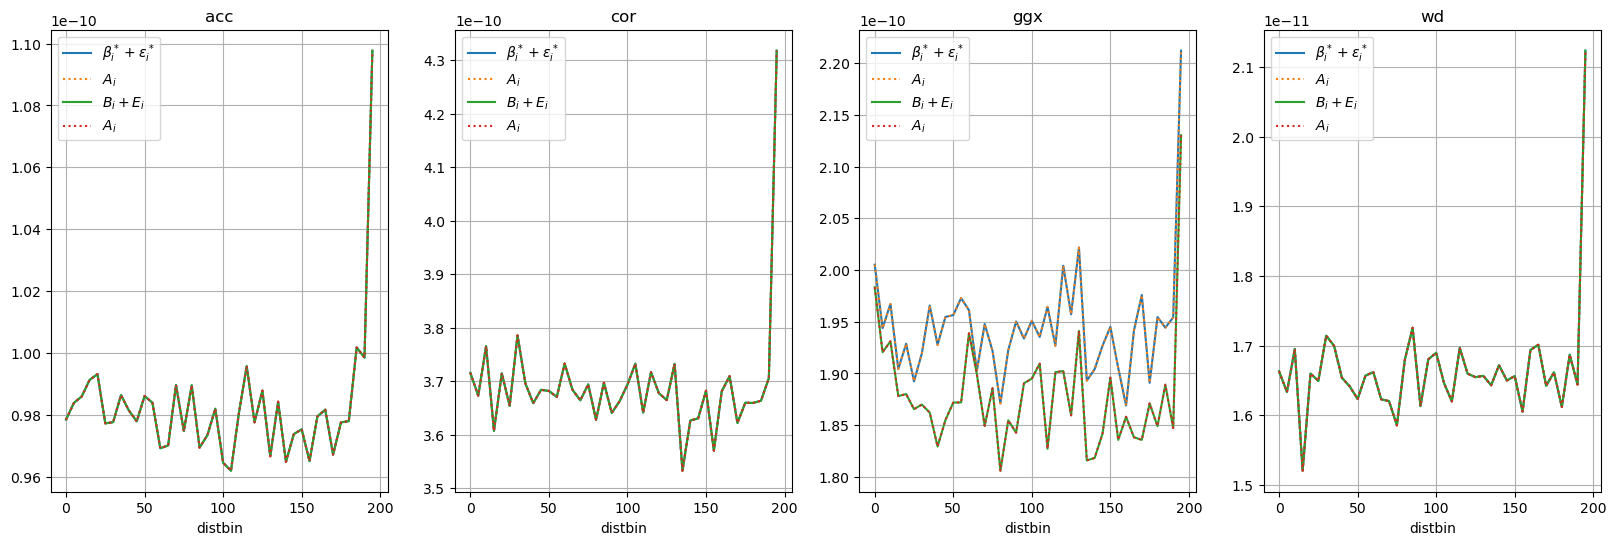

In [57]:
fig, axs = plt.subplots(1, 4, figsize=(20, 6))
axs = axs.flatten()
for i in range(len(var)):
    ax = axs[i]
    v, vd = var[i], vard[i]
    (
        df.groupby("distbin")["b_" + v].mean() + df.groupby("distbin")[v + "s"].mean()
    ).plot(label=r"$\beta^*_i + \epsilon^*_i$", ax=ax)
    (df2.groupby("distbin")[v].mean()).plot(label=r"$A_i$", ax=ax, ls=":")

    (
        df.groupby("distbin")["bd_" + vd].mean()
        + df.groupby("distbin")[vd + "sd"].mean()
    ).plot(label=r"$B_i + E_i$", ax=ax)
    (df2.groupby("distbin")[vd].mean()).plot(label=r"$A_i$", ax=ax, ls=":")
    ax.grid()
    ax.set_title(v)
    ax.legend()

## Pairs contributions $X_{ij} = -2\langle a_i a_j \rangle$ en fonction de $X_{ijeq} = -2\langle a_i a_j \rangle$

- Pour l'équilibre sans erreur de colocalisation:
  $X_{ij} = -2\langle b_i b_j \rangle$ ne dépend pas de dl
  
- Pour l'équilibre avec erreur de colocalisation:
    - pour $i,j\neq 3$ :
      $$X^*_{ij} = X_{ij} = -2\langle b_i b_j \rangle$$
    - pour $i=3$, $j\neq 3$, par exemple j=1:
      $$X^*_{3i} = -2\langle a^*_3 a_i \rangle = -2\langle (a^*_3-a_3+a_3) a_i \rangle = -2\langle d_3 a_i \rangle + X_{3i}$$
- On remarque que $\sum X_{ij} = \sum_i B_i$

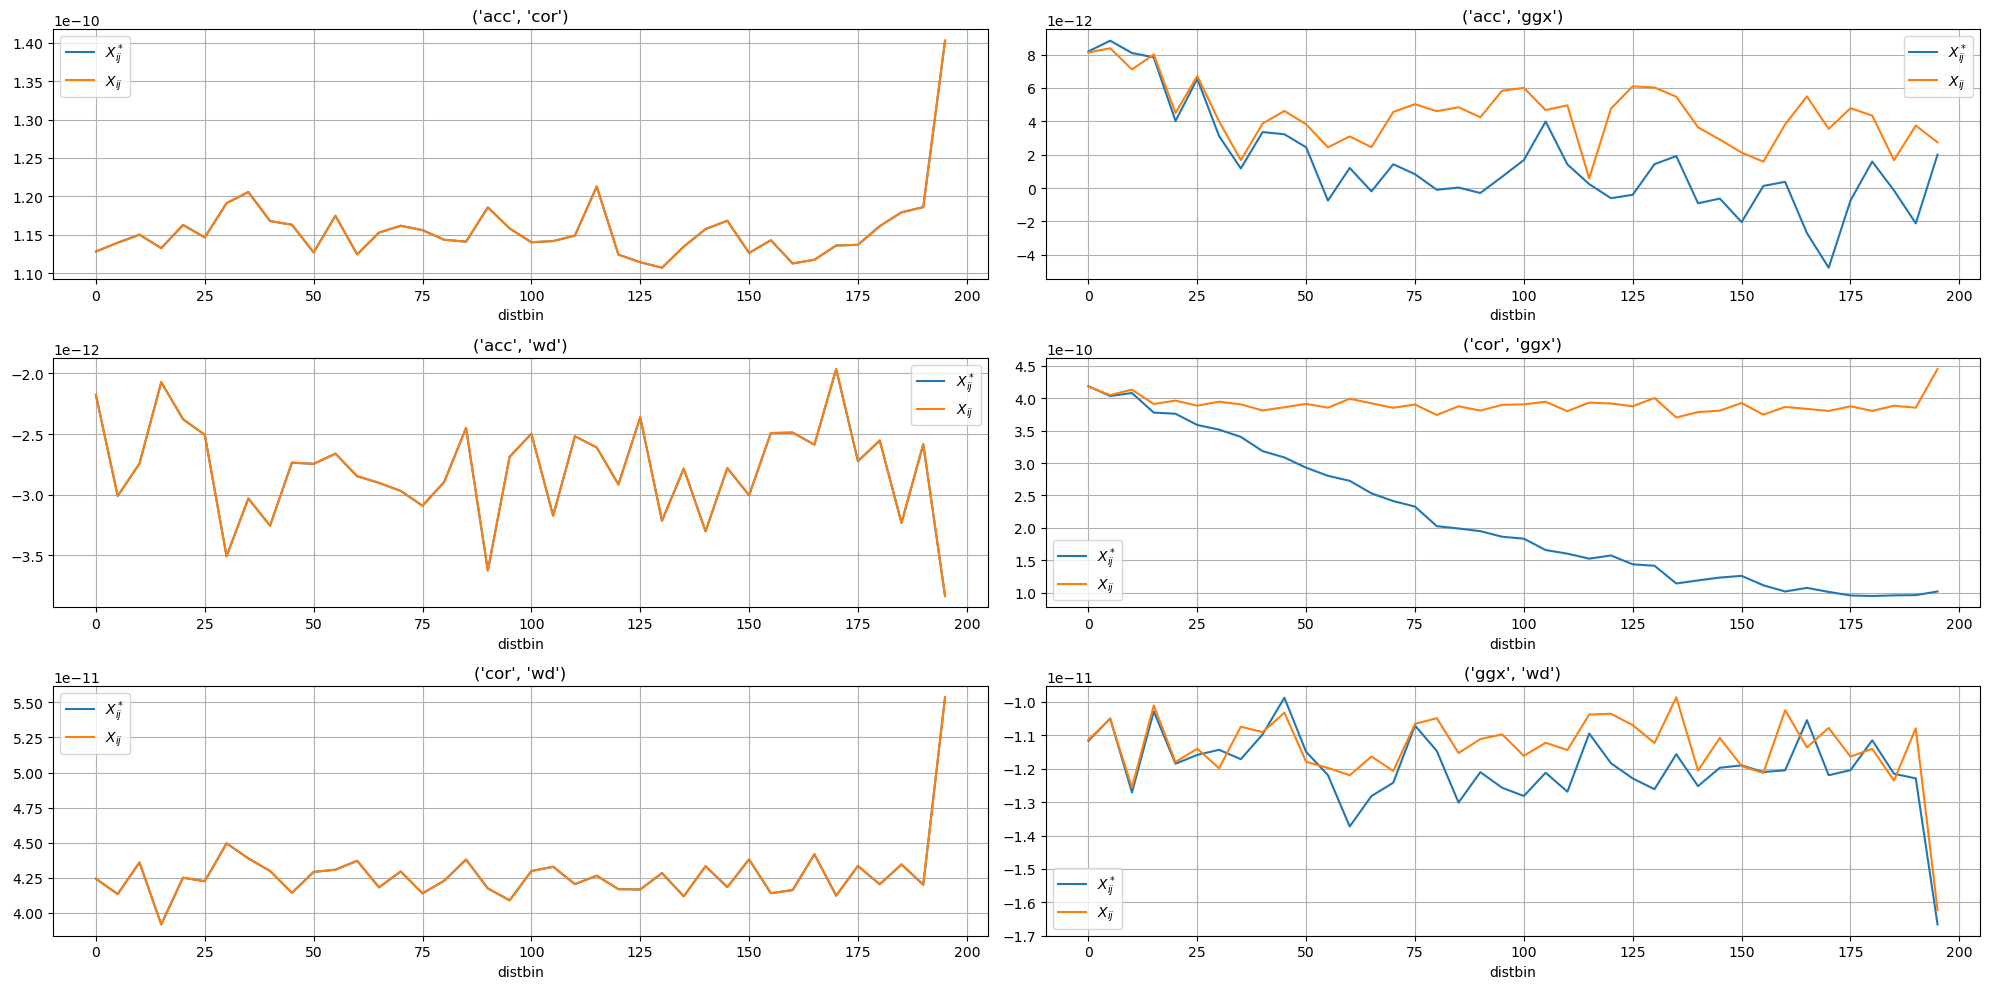

In [58]:
fig, axs = plt.subplots(3, 2, figsize=(20, 10))
axs = axs.flatten()
for i in range(len(comb)):
    ax = axs[i]
    c, cd = comb[i], combd[i]
    (-2 * df.groupby("distbin")[f"{c[0]}_{c[1]}"].mean()).plot(
        label=r"$X^*_{ij}$", ax=ax
    )
    (-2 * df.groupby("distbin")[f"{cd[0]}_{cd[1]}"].mean()).plot(
        label=r"$X_{ij}$", ax=ax
    )
    ax.grid()
    ax.set_title(c)
    ax.legend()
fig.tight_layout()

## A propos de $\Sigma$
$$\Sigma = \sum_i A_i = \sum_i B_i +\sum_i E_i $$ 
$\Sigma$ n'est pas impacté par l'erreur de colocalisation, et on a : $$\Sigma - \Sigma^* = A'_3-A_3$$

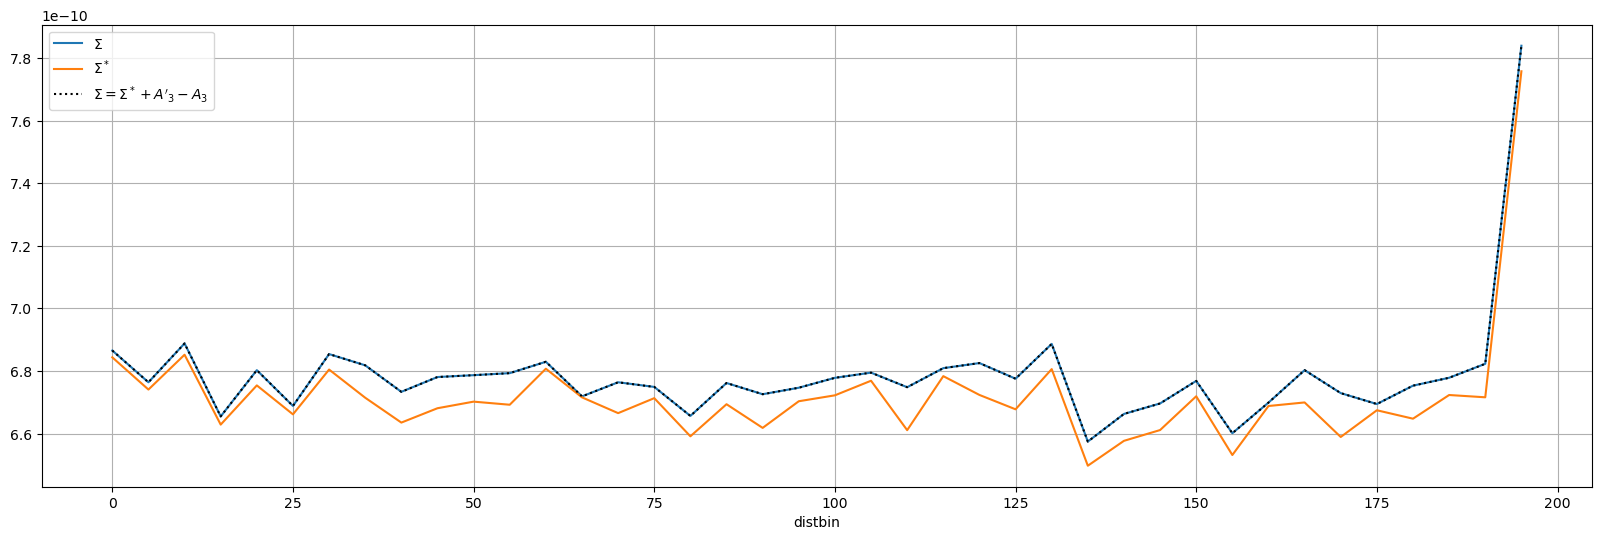

In [59]:
df2["sig"] = df2[[v for v in var]].sum(axis=1)
df2["sigd"] = df2[[v for v in vard]].sum(axis=1)
fig, ax = plt.subplots(1, 1, figsize=(20, 6))
df2.groupby("distbin")["sig"].mean().plot(label=r"$\Sigma$", ax=ax)
df2.groupby("distbin")["sigd"].mean().plot(label=r"$\Sigma^*$", ax=ax)
(
    df2.groupby("distbin")["sigd"].mean()
    + df2.groupby("distbin")["ggx"].mean()
    - df2.groupby("distbin")["ggxd"].mean()
).plot(label=r"$\Sigma = \Sigma^* + A'_3-A_3$", ax=ax, ls=":", c="k")
ax.grid()
ax.legend()

In [49]:
df["sumb"] = df[["b_" + v for v in var]].sum(axis=1)
df["sumbd"] = df[["bd_" + v for v in vard]].sum(axis=1)
df["sume"] = df[[v + "s" for v in var]].sum(axis=1)
df["sumed"] = df[[v + "sd" for v in vard]].sum(axis=1)

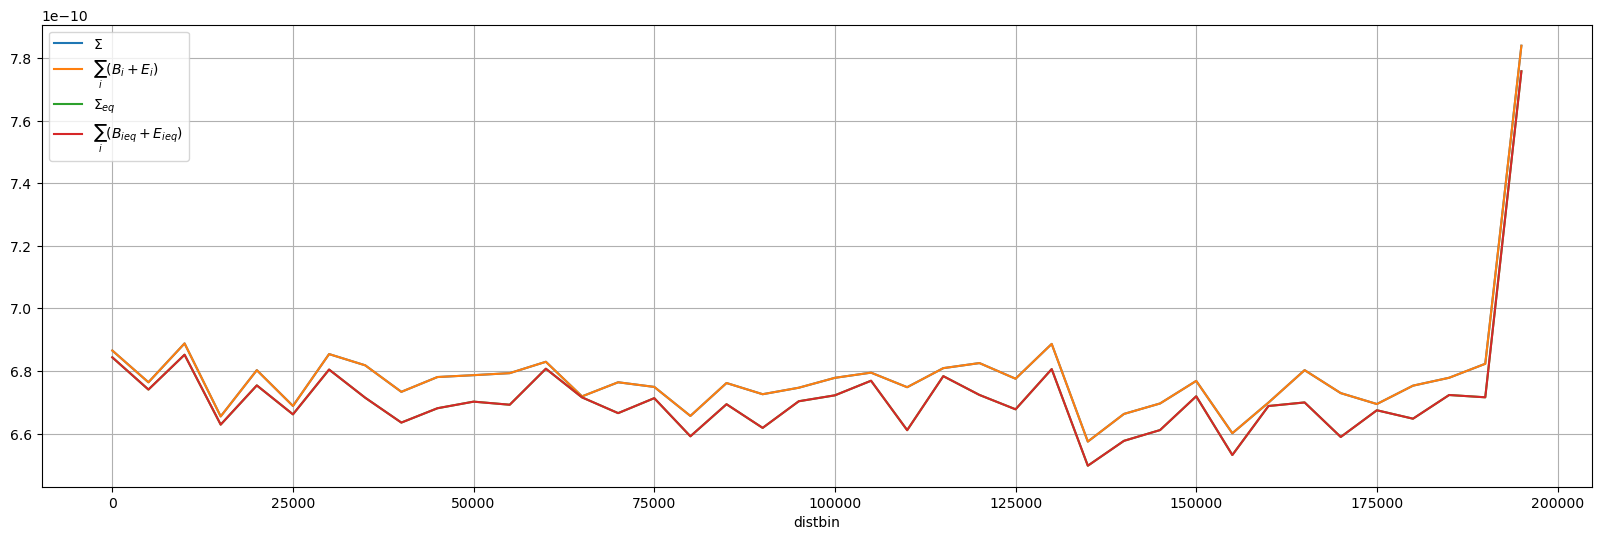

In [50]:
fig, ax = plt.subplots(1, 1, figsize=(20, 6))

df2.groupby("distbin")["sig"].mean().plot(label=r"$\Sigma$", ax=ax)
(df.groupby("distbin")["sumb"].mean() + df.groupby("distbin")["sume"].mean()).plot(
    label=r"$\sum_i(B_i+E_i)$", ax=ax
)

df2.groupby("distbin")["sigd"].mean().plot(label=r"$\Sigma^*$", ax=ax)
(df.groupby("distbin")["sumbd"].mean() + df.groupby("distbin")["sumed"].mean()).plot(
    label=r"$\sum_i(B_i+E_i)$", ax=ax
)
ax.grid()
ax.legend()

# Différence A_3/A'_3 ??
A priori, ne devait pas avoir de grosse différences, ni de tendance, mais sur tout les DL on a globalement A'_3 < A_3, mais pourquoi ???

<Axes: >

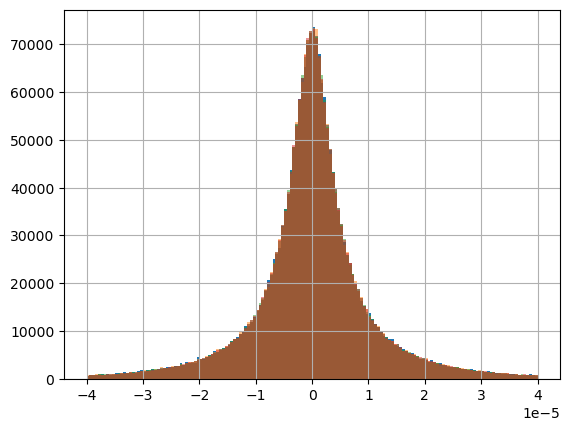

In [51]:
df_.ggx.hist(bins=np.arange(-4e-5, 4e-5, 5e-7), density=True)
df_.ggxd.hist(bins=np.arange(-4e-5, 4e-5, 5e-7), density=True, alpha=0.5)
df.ggx.hist(bins=np.arange(-4e-5, 4e-5, 5e-7), density=True, alpha=0.5)
df.ggxd.hist(bins=np.arange(-4e-5, 4e-5, 5e-7), density=True, alpha=0.5)

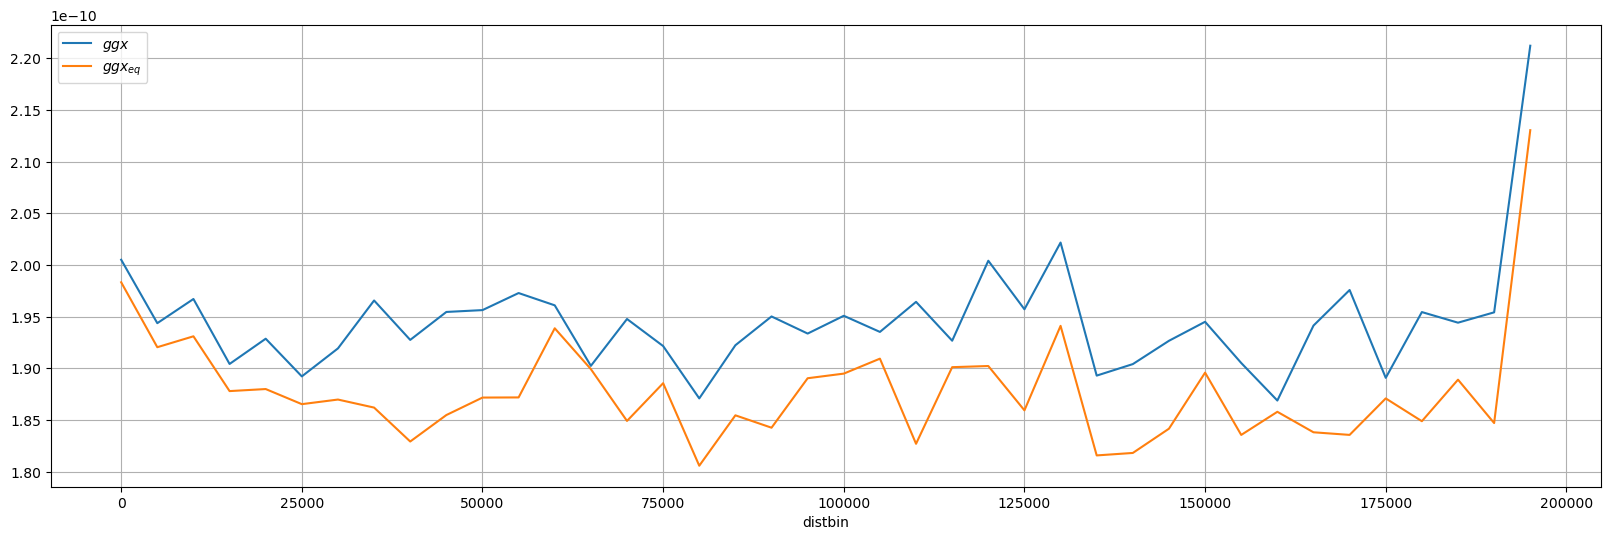

In [52]:
fig, ax = plt.subplots(1, 1, figsize=(20, 6))
df2.groupby("distbin")["ggx"].mean().plot(label=r"$ggx$", ax=ax)
df2.groupby("distbin")["ggxd"].mean().plot(label=r"$ggx^*$", ax=ax)
ax.grid()
ax.legend()

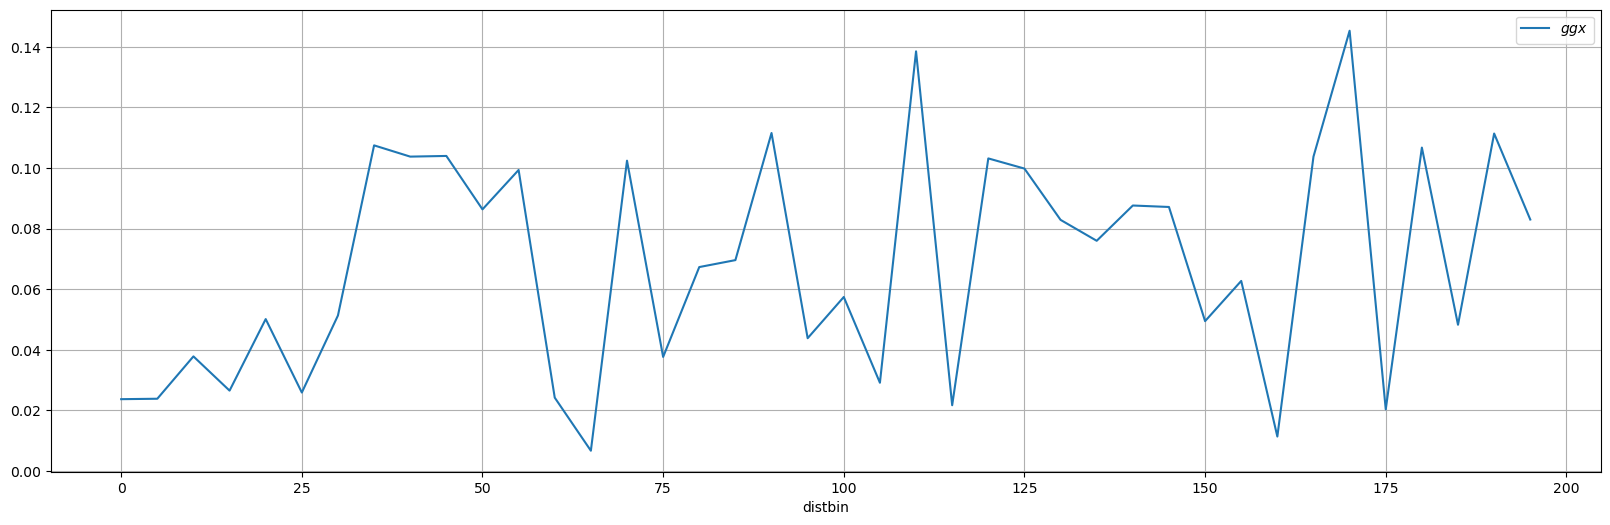

In [158]:
fig, ax = plt.subplots(1, 1, figsize=(20, 6))
(df2.groupby("distbin")["ggx"].mean() - df2.groupby("distbin")["ggxd"].mean()).plot(
    label=r"$ggx$", ax=ax
)
ax.grid()
ax.legend()

- pas facile (impossible ?) d'estimer le $\langle a_i d_3 \rangle$
- Pour le along-track, je peux connaître un $\langle d_3 \rangle$ et un $d_k$ et $A_3 - A'_3$ en fonction de DL mais seulement sur la direction de la trace ... un $\langle a'_3 d_3 \rangle$ aussi ?
- L'origine sur les courbes sans DL donne une idée

In [9]:
cluster.close()